# EDA: Multicube Teleop + DAgger Dataset

Exploratory data analysis for the multicube goal-conditioned task (Exercise 3).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import zarr
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# Load all multicube zarr stores (teleop + dagger)
base = Path("datasets/raw/multi_cube")
zarr_paths = sorted(base.rglob("*.zarr"))

data_arrays = {}
all_ep_ends = []
ep_sources = []  # "teleop" or "dagger" per episode
offset = 0

for zp in zarr_paths:
    root = zarr.open_group(str(zp), mode="r")
    ep_ends = np.asarray(root["meta"]["episode_ends"])
    if ep_ends.size == 0:
        continue
    n_steps = int(ep_ends[-1])
    all_ep_ends.append(ep_ends + offset)
    source = "dagger" if "dagger" in str(zp) else "teleop"
    ep_sources.extend([source] * ep_ends.size)
    for key in root["data"]:
        arr = np.asarray(root["data"][key][:n_steps])
        data_arrays.setdefault(key, []).append(arr)
    offset += n_steps
    print(f"  {zp.relative_to(base)}: {ep_ends.size} eps, {n_steps} steps [{source}]")

# Concatenate
for key in data_arrays:
    data_arrays[key] = np.concatenate(data_arrays[key], axis=0)
episode_ends = np.concatenate(all_ep_ends)
episode_starts = np.concatenate([[0], episode_ends[:-1]])
ep_sources = np.array(ep_sources)

n_teleop = (ep_sources == "teleop").sum()
n_dagger = (ep_sources == "dagger").sum()

print(f"\nTotal episodes: {episode_ends.size} ({n_teleop} teleop, {n_dagger} dagger)")
print(f"Total timesteps: {offset}")
print(f"\nData keys and shapes:")
for key in sorted(data_arrays):
    print(f"  {key}: {data_arrays[key].shape} ({data_arrays[key].dtype})")

/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw3_imitation_learning/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


  dagger/2026-03-24_22-52-51/so100_multicube_teleop.zarr: 4 eps, 899 steps [dagger]
  dagger/2026-03-24_22-59-17/so100_multicube_teleop.zarr: 1 eps, 327 steps [dagger]
  dagger/2026-03-24_23-04-51/so100_multicube_teleop.zarr: 3 eps, 538 steps [dagger]
  dagger/2026-03-25_15-24-09/so100_multicube_teleop.zarr: 6 eps, 934 steps [dagger]
  teleop/2026-03-24_22-22-32/so100_multicube_teleop.zarr: 31 eps, 8514 steps [teleop]
  teleop/2026-03-25_15-04-15/so100_multicube_teleop.zarr: 21 eps, 5202 steps [teleop]

Total episodes: 66 (52 teleop, 14 dagger)
Total timesteps: 16414

Data keys and shapes:
  action_gripper: (16414, 1) (float32)
  goal_pos: (16414, 3) (float32)
  pos_cube_blue: (16414, 7) (float32)
  pos_cube_green: (16414, 7) (float32)
  pos_cube_red: (16414, 7) (float32)
  state_ee: (16414, 7) (float32)
  state_goal: (16414, 3) (float32)
  state_gripper: (16414, 1) (float32)
  state_joints: (16414, 6) (float32)
  state_obstacle: (16414, 3) (float32)


## 1. Episode Length Distribution (Teleop vs DAgger)

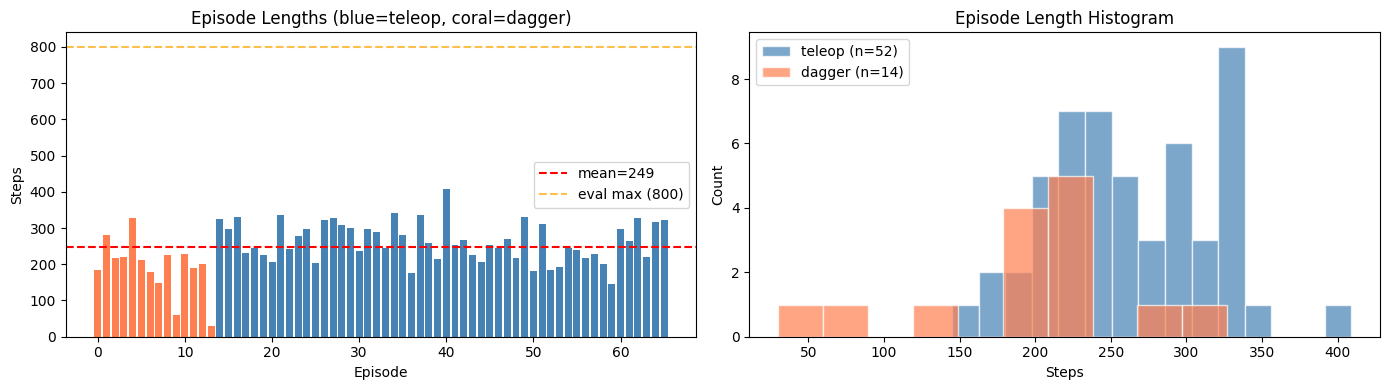

Teleop: 52 eps, mean=264, total=13716 steps
DAgger: 14 eps, mean=193, total=2698 steps


In [2]:
ep_lengths = np.diff(np.concatenate([[0], episode_ends]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Color by source
bar_colors = ["steelblue" if s == "teleop" else "coral" for s in ep_sources]
axes[0].bar(range(len(ep_lengths)), ep_lengths, color=bar_colors)
axes[0].axhline(ep_lengths.mean(), color="red", ls="--", label=f"mean={ep_lengths.mean():.0f}")
axes[0].axhline(800, color="orange", ls="--", alpha=0.7, label="eval max (800)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Steps")
axes[0].set_title("Episode Lengths (blue=teleop, coral=dagger)")
axes[0].legend()

# Separate histograms
teleop_lens = ep_lengths[ep_sources == "teleop"]
dagger_lens = ep_lengths[ep_sources == "dagger"]
axes[1].hist(teleop_lens, bins=15, color="steelblue", edgecolor="white", alpha=0.7, label=f"teleop (n={len(teleop_lens)})")
if len(dagger_lens) > 0:
    axes[1].hist(dagger_lens, bins=10, color="coral", edgecolor="white", alpha=0.7, label=f"dagger (n={len(dagger_lens)})")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Count")
axes[1].set_title("Episode Length Histogram")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Teleop: {len(teleop_lens)} eps, mean={teleop_lens.mean():.0f}, total={teleop_lens.sum()} steps")
if len(dagger_lens) > 0:
    print(f"DAgger: {len(dagger_lens)} eps, mean={dagger_lens.mean():.0f}, total={dagger_lens.sum()} steps")

## 2. Goal Distribution

Which cube colors are targeted across episodes? Check for imbalance.

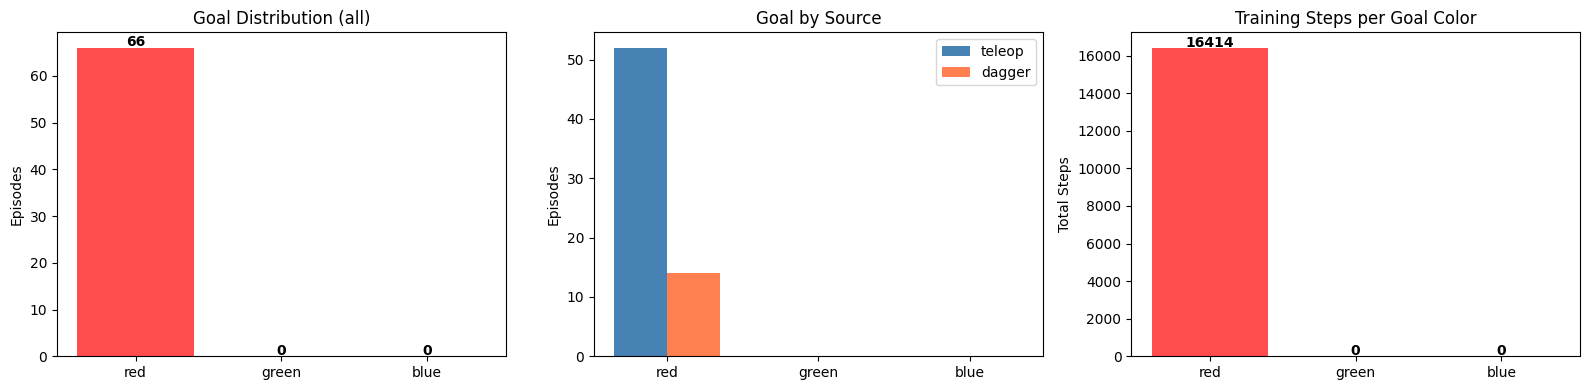

In [3]:
goal = data_arrays["state_goal"]  # (N, 3) one-hot: [red, green, blue]
CUBE_COLORS = ["red", "green", "blue"]
COLOR_MAP = {"red": "red", "green": "green", "blue": "blue"}

# Get goal per episode (constant within episode)
goal_per_ep = np.array([goal[s] for s in episode_starts])
goal_labels = [CUBE_COLORS[g.argmax()] for g in goal_per_ep]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall goal distribution
counts = [goal_labels.count(c) for c in CUBE_COLORS]
axes[0].bar(CUBE_COLORS, counts, color=["red", "green", "blue"], alpha=0.7)
axes[0].set_ylabel("Episodes")
axes[0].set_title("Goal Distribution (all)")
for i, c in enumerate(counts):
    axes[0].text(i, c + 0.3, str(c), ha="center", fontweight="bold")

# Teleop vs DAgger breakdown
teleop_goals = [goal_labels[i] for i in range(len(goal_labels)) if ep_sources[i] == "teleop"]
dagger_goals = [goal_labels[i] for i in range(len(goal_labels)) if ep_sources[i] == "dagger"]

x = np.arange(3)
w = 0.35
t_counts = [teleop_goals.count(c) for c in CUBE_COLORS]
d_counts = [dagger_goals.count(c) for c in CUBE_COLORS]
axes[1].bar(x - w/2, t_counts, w, color="steelblue", label="teleop")
axes[1].bar(x + w/2, d_counts, w, color="coral", label="dagger")
axes[1].set_xticks(x)
axes[1].set_xticklabels(CUBE_COLORS)
axes[1].set_ylabel("Episodes")
axes[1].set_title("Goal by Source")
axes[1].legend()

# Steps per goal color
steps_per_color = {}
for c in CUBE_COLORS:
    mask = np.array([g == c for g in goal_labels])
    steps_per_color[c] = ep_lengths[mask].sum()
axes[2].bar(CUBE_COLORS, [steps_per_color[c] for c in CUBE_COLORS],
            color=["red", "green", "blue"], alpha=0.7)
axes[2].set_ylabel("Total Steps")
axes[2].set_title("Training Steps per Goal Color")
for i, c in enumerate(CUBE_COLORS):
    axes[2].text(i, steps_per_color[c] + 50, str(steps_per_color[c]), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 3. End-Effector Trajectories (XYZ)

Per episode, colored by goal cube.

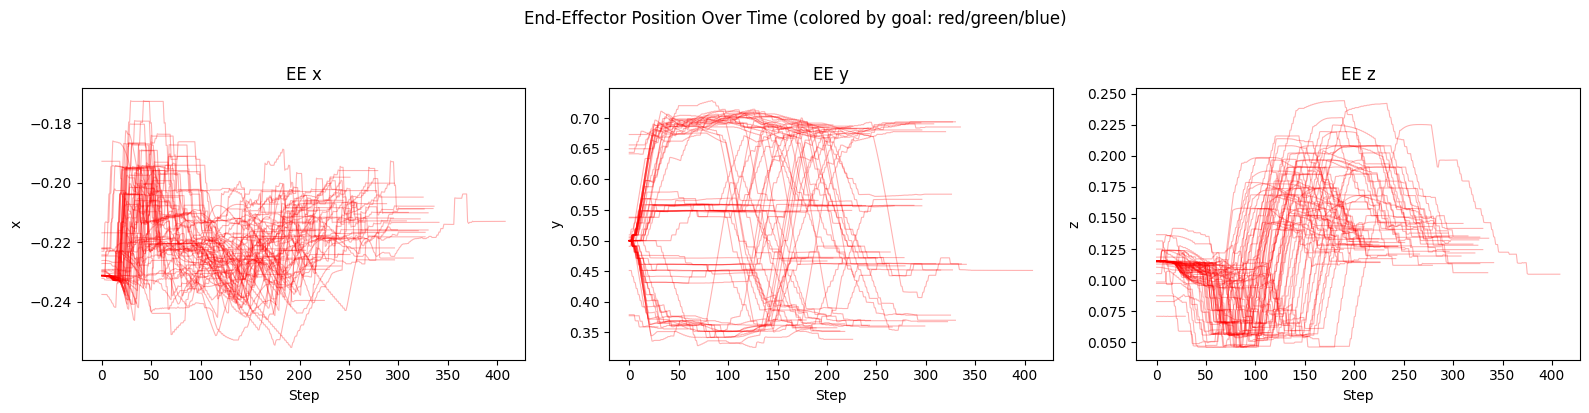

In [4]:
ee = data_arrays["state_ee"]  # (N, 7): x, y, z, qw, qx, qy, qz
labels = ["x", "y", "z"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for dim, (ax, label) in enumerate(zip(axes, labels)):
    for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
        c = COLOR_MAP[goal_labels[i]]
        ax.plot(np.arange(e - s), ee[s:e, dim], alpha=0.3, lw=0.8, color=c)
    ax.set_xlabel("Step")
    ax.set_ylabel(label)
    ax.set_title(f"EE {label}")
plt.suptitle("End-Effector Position Over Time (colored by goal: red/green/blue)", y=1.02)
plt.tight_layout()
plt.show()

## 4. EE Trajectories 2D (Top-down XY, Side XZ)

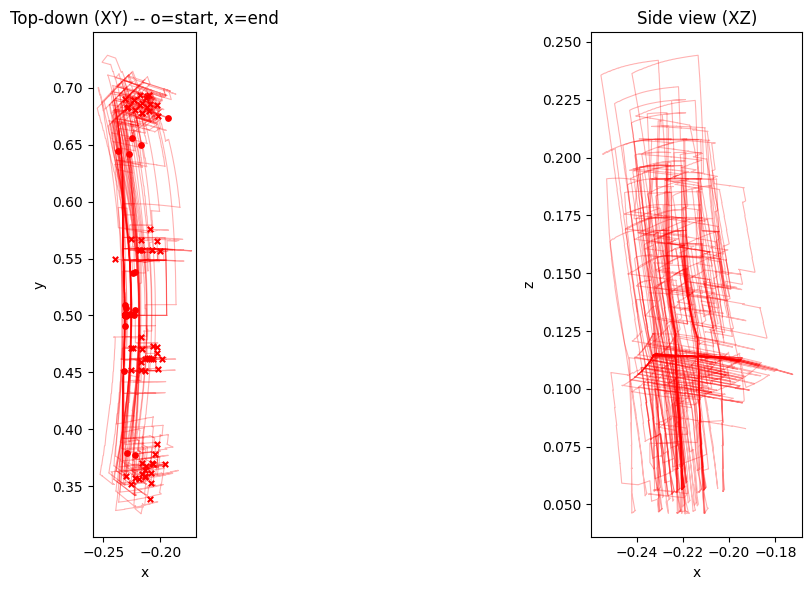

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    c = COLOR_MAP[goal_labels[i]]
    axes[0].plot(ee[s:e, 0], ee[s:e, 1], alpha=0.3, lw=0.8, color=c)
    axes[0].scatter(ee[s, 0], ee[s, 1], marker="o", s=15, color=c, zorder=5)
    axes[0].scatter(ee[e-1, 0], ee[e-1, 1], marker="x", s=15, color=c, zorder=5)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Top-down (XY) -- o=start, x=end")
axes[0].set_aspect("equal")

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    c = COLOR_MAP[goal_labels[i]]
    axes[1].plot(ee[s:e, 0], ee[s:e, 2], alpha=0.3, lw=0.8, color=c)

axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
axes[1].set_title("Side view (XZ)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## 5. All Three Cube Positions Over Time

Track where each cube goes during episodes. The goal cube should move to the bin; distractors should stay put.

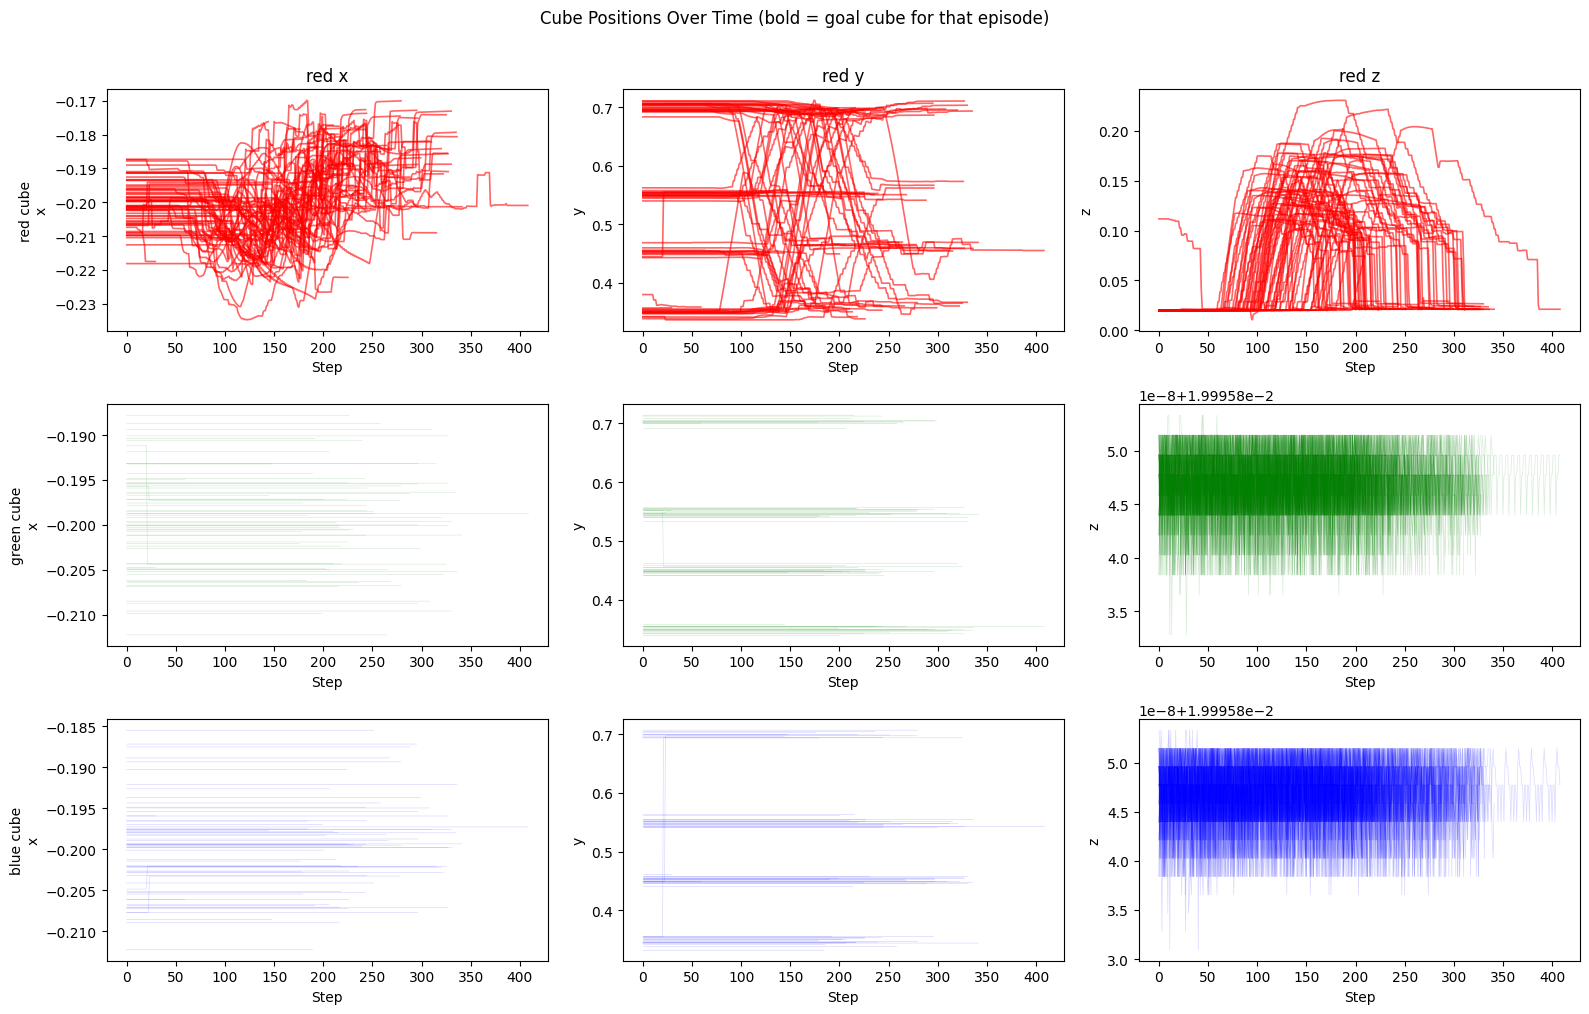

Goal cube displacement (start -> end) per episode:
  Ep  0 [dagger] goal=red  : dist_to_bin 0.130 -> 0.011  [OK]
  Ep  1 [dagger] goal=red  : dist_to_bin 0.259 -> 0.022  [OK]
  Ep  2 [dagger] goal=red  : dist_to_bin 0.097 -> 0.022  [OK]
  Ep  3 [dagger] goal=red  : dist_to_bin 0.111 -> 0.024  [OK]
  Ep  4 [dagger] goal=red  : dist_to_bin 0.144 -> 0.018  [OK]
  Ep  5 [dagger] goal=red  : dist_to_bin 0.336 -> 0.021  [OK]
  Ep  6 [dagger] goal=red  : dist_to_bin 0.089 -> 0.020  [OK]
  Ep  7 [dagger] goal=red  : dist_to_bin 0.200 -> 0.008  [OK]
  Ep  8 [dagger] goal=red  : dist_to_bin 0.075 -> 0.006  [OK]
  Ep  9 [dagger] goal=red  : dist_to_bin 0.028 -> 0.010  [OK]
  Ep 10 [dagger] goal=red  : dist_to_bin 0.356 -> 0.006  [OK]
  Ep 11 [dagger] goal=red  : dist_to_bin 0.357 -> 0.013  [OK]
  Ep 12 [dagger] goal=red  : dist_to_bin 0.262 -> 0.014  [OK]
  Ep 13 [dagger] goal=red  : dist_to_bin 0.334 -> 0.333  [MISS]
  Ep 14 [teleop] goal=red  : dist_to_bin 0.263 -> 0.022  [OK]
  Ep 15 [teleop] 

In [6]:
cube_red = data_arrays["pos_cube_red"][:, :3]
cube_green = data_arrays["pos_cube_green"][:, :3]
cube_blue = data_arrays["pos_cube_blue"][:, :3]

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
cube_data = {"red": cube_red, "green": cube_green, "blue": cube_blue}
xyz_labels = ["x", "y", "z"]

for row, (color, cube) in enumerate(cube_data.items()):
    for dim in range(3):
        ax = axes[row, dim]
        for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
            is_goal = goal_labels[i] == color
            alpha = 0.6 if is_goal else 0.15
            lw = 1.2 if is_goal else 0.5
            ax.plot(np.arange(e - s), cube[s:e, dim], alpha=alpha, lw=lw,
                    color=COLOR_MAP[color])
        ax.set_xlabel("Step")
        ax.set_ylabel(xyz_labels[dim])
        if dim == 0:
            ax.set_ylabel(f"{color} cube\n{xyz_labels[dim]}")
        ax.set_title(f"{color} {xyz_labels[dim]}" if row == 0 else "")

plt.suptitle("Cube Positions Over Time (bold = goal cube for that episode)", y=1.01)
plt.tight_layout()
plt.show()

# Check: does the goal cube actually reach the bin?
goal_pos = data_arrays["goal_pos"]  # bin position
print("Goal cube displacement (start -> end) per episode:")
for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    gc = goal_labels[i]
    cube = cube_data[gc]
    dist_start = np.linalg.norm(cube[s, :2] - goal_pos[s, :2])
    dist_end = np.linalg.norm(cube[e-1, :2] - goal_pos[e-1, :2])
    success = dist_end < 0.05
    tag = "OK" if success else "MISS"
    src = ep_sources[i]
    print(f"  Ep {i:2d} [{src:6s}] goal={gc:5s}: dist_to_bin {dist_start:.3f} -> {dist_end:.3f}  [{tag}]")

## 6. Cube Initial Positions & Bin Position Distribution

Where do cubes and bin spawn across episodes?

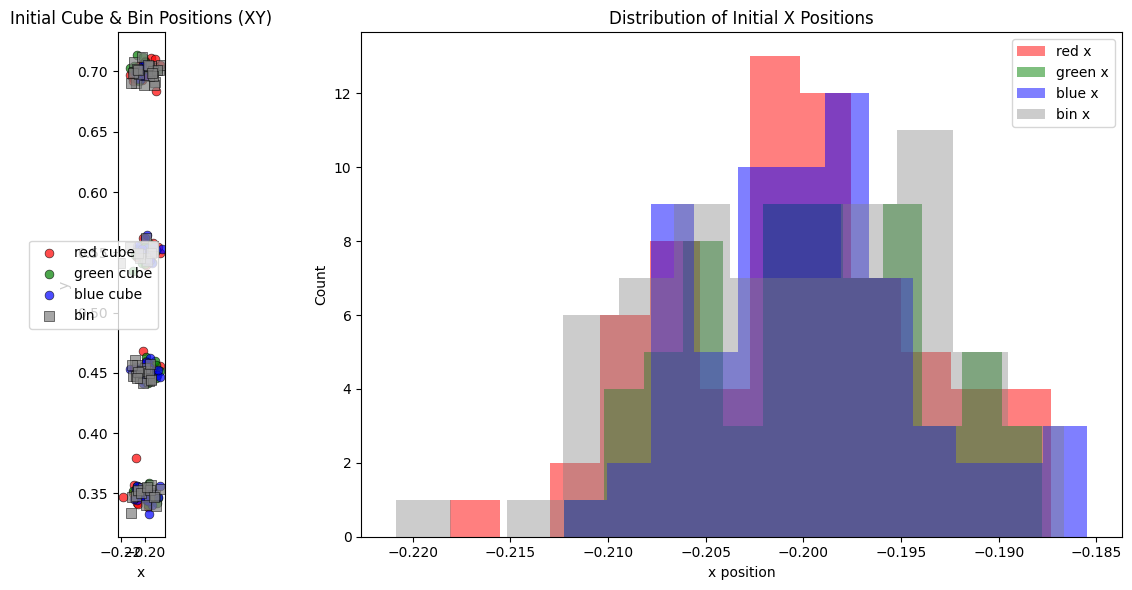

red   cube init: x=[-0.218, -0.187], y=[0.339, 0.711]
green cube init: x=[-0.212, -0.188], y=[0.341, 0.713]
blue  cube init: x=[-0.212, -0.185], y=[0.333, 0.707]
bin   pos:      x=[-0.221, -0.187], y=[0.334, 0.712]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Initial positions of all 3 cubes
for color, cube in cube_data.items():
    init_pos = np.array([cube[s] for s in episode_starts])
    axes[0].scatter(init_pos[:, 0], init_pos[:, 1], c=COLOR_MAP[color],
                    label=f"{color} cube", alpha=0.7, s=40, edgecolors="k", lw=0.5)

# Bin positions
gp = np.array([goal_pos[s] for s in episode_starts])
axes[0].scatter(gp[:, 0], gp[:, 1], c="gray", marker="s", s=60, label="bin",
                alpha=0.7, edgecolors="k", lw=0.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Initial Cube & Bin Positions (XY)")
axes[0].legend()
axes[0].set_aspect("equal")

# Distribution of initial cube x positions
for color, cube in cube_data.items():
    init_x = np.array([cube[s, 0] for s in episode_starts])
    axes[1].hist(init_x, bins=12, alpha=0.5, color=COLOR_MAP[color], label=f"{color} x")
bin_x = gp[:, 0]
axes[1].hist(bin_x, bins=12, alpha=0.4, color="gray", label="bin x")
axes[1].set_xlabel("x position")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Initial X Positions")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print ranges
for color, cube in cube_data.items():
    init = np.array([cube[s] for s in episode_starts])
    print(f"{color:5s} cube init: x=[{init[:,0].min():.3f}, {init[:,0].max():.3f}], "
          f"y=[{init[:,1].min():.3f}, {init[:,1].max():.3f}]")
print(f"{'bin':5s} pos:      x=[{gp[:,0].min():.3f}, {gp[:,0].max():.3f}], "
      f"y=[{gp[:,1].min():.3f}, {gp[:,1].max():.3f}]")

## 7. Gripper Actions & State

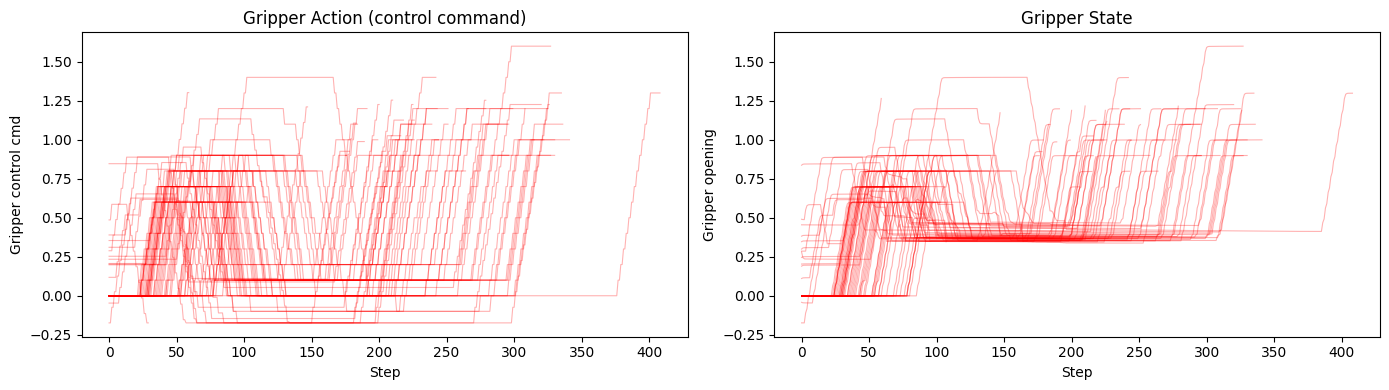

Gripper action range: [-0.1740, 1.6000]
Gripper state range:  [-0.1731, 1.5993]


In [8]:
gripper_action = data_arrays["action_gripper"].squeeze()
gripper_state = data_arrays["state_gripper"].squeeze()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    c = COLOR_MAP[goal_labels[i]]
    axes[0].plot(np.arange(e - s), gripper_action[s:e], alpha=0.3, lw=0.8, color=c)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Gripper control cmd")
axes[0].set_title("Gripper Action (control command)")

for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    c = COLOR_MAP[goal_labels[i]]
    axes[1].plot(np.arange(e - s), gripper_state[s:e], alpha=0.3, lw=0.8, color=c)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Gripper opening")
axes[1].set_title("Gripper State")

plt.tight_layout()
plt.show()

print(f"Gripper action range: [{gripper_action.min():.4f}, {gripper_action.max():.4f}]")
print(f"Gripper state range:  [{gripper_state.min():.4f}, {gripper_state.max():.4f}]")

## 8. Delta Actions (EE XYZ)

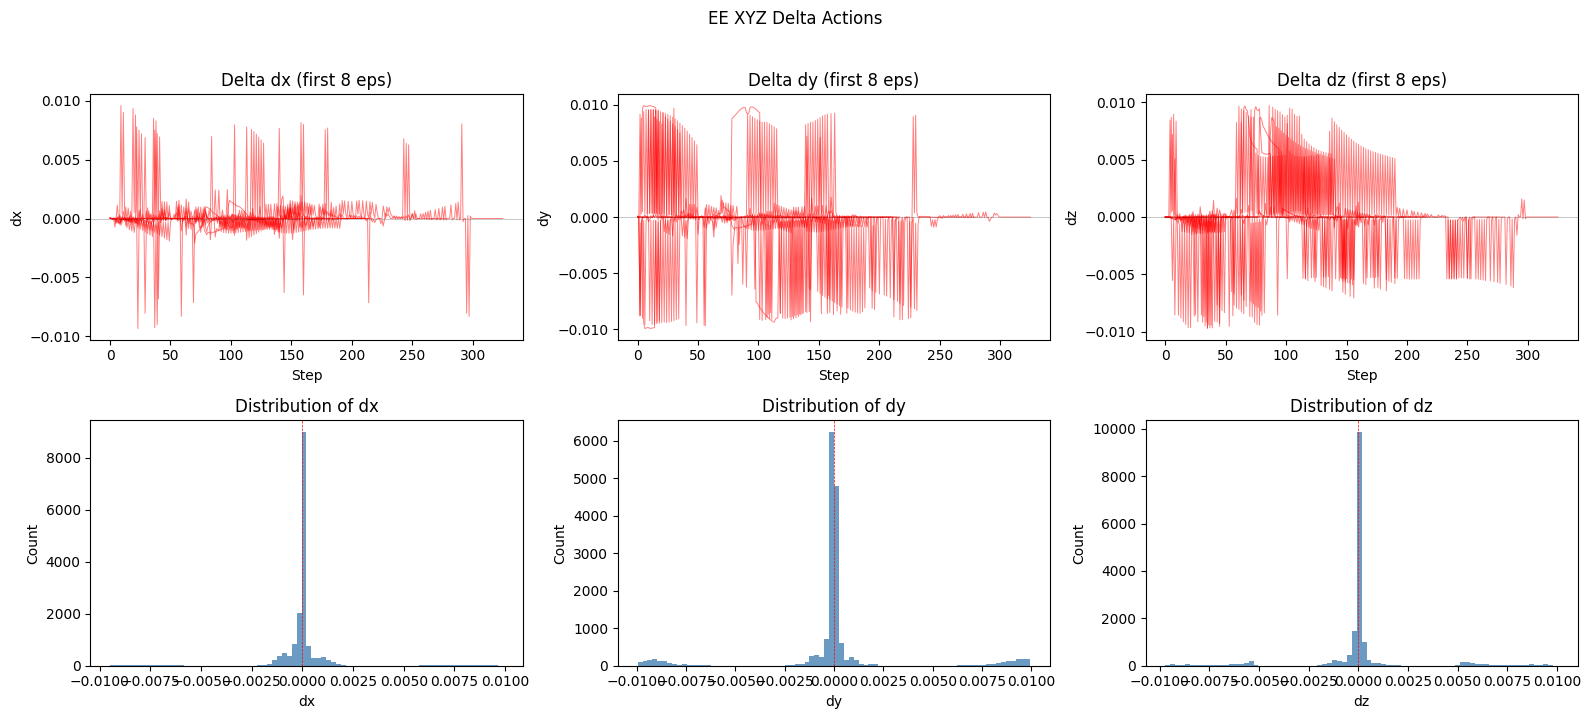

Near-zero deltas (||delta|| < 1e-05): 5981/16348 (36.6%)
Delta magnitude: mean=0.002633, std=0.003737, max=0.010052


In [9]:
ee_xyz = ee[:, :3]
labels_d = ["dx", "dy", "dz"]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

for dim, label in enumerate(labels_d):
    for i, (s, e) in enumerate(zip(episode_starts[:8], episode_ends[:8])):
        deltas = ee_xyz[s+1:e, dim] - ee_xyz[s:e-1, dim]
        c = COLOR_MAP[goal_labels[i]]
        axes[0, dim].plot(np.arange(len(deltas)), deltas, alpha=0.5, lw=0.7, color=c)
    axes[0, dim].set_xlabel("Step")
    axes[0, dim].set_ylabel(label)
    axes[0, dim].set_title(f"Delta {label} (first 8 eps)")
    axes[0, dim].axhline(0, color="k", lw=0.5, alpha=0.3)

    all_deltas = []
    for s, e in zip(episode_starts, episode_ends):
        all_deltas.append(ee_xyz[s+1:e, dim] - ee_xyz[s:e-1, dim])
    all_deltas = np.concatenate(all_deltas)
    axes[1, dim].hist(all_deltas, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    axes[1, dim].set_xlabel(label)
    axes[1, dim].set_ylabel("Count")
    axes[1, dim].set_title(f"Distribution of {label}")
    axes[1, dim].axvline(0, color="red", lw=0.5, ls="--")

plt.suptitle("EE XYZ Delta Actions", y=1.02)
plt.tight_layout()
plt.show()

all_d = []
for s, e in zip(episode_starts, episode_ends):
    all_d.append(np.linalg.norm(ee_xyz[s+1:e] - ee_xyz[s:e-1], axis=1))
all_d = np.concatenate(all_d)
idle_thresh = 1e-5
print(f"Near-zero deltas (||delta|| < {idle_thresh}): {(all_d < idle_thresh).sum()}/{len(all_d)} "
      f"({100*(all_d < idle_thresh).mean():.1f}%)")
print(f"Delta magnitude: mean={all_d.mean():.6f}, std={all_d.std():.6f}, max={all_d.max():.6f}")

## 9. Distractor Cube Movement

Do non-goal cubes stay still? Large movements = accidental bumps during teleop.

In [10]:
print("Distractor cube max displacement (should be ~0 for clean demos):\n")
print(f"{'Ep':>3s}  {'Src':6s}  {'Goal':5s}  {'Red disp':>10s}  {'Green disp':>10s}  {'Blue disp':>10s}")
print("-" * 55)

bumped_eps = []
for i, (s, e) in enumerate(zip(episode_starts, episode_ends)):
    gc = goal_labels[i]
    disps = {}
    for color, cube in cube_data.items():
        disp = np.linalg.norm(cube[e-1] - cube[s])
        disps[color] = disp
    
    # Flag if any distractor moved > 3cm
    distractor_moved = any(disps[c] > 0.03 for c in CUBE_COLORS if c != gc)
    tag = " <<<" if distractor_moved else ""
    if distractor_moved:
        bumped_eps.append(i)
    
    print(f"{i:3d}  {ep_sources[i]:6s}  {gc:5s}  "
          f"{disps['red']:10.4f}  {disps['green']:10.4f}  {disps['blue']:10.4f}{tag}")

print(f"\nEpisodes with bumped distractors (>3cm): {len(bumped_eps)}/{len(episode_ends)}")

Distractor cube max displacement (should be ~0 for clean demos):

 Ep  Src     Goal     Red disp  Green disp   Blue disp
-------------------------------------------------------
  0  dagger  red        0.1289      0.0000      0.0000
  1  dagger  red        0.2466      0.0000      0.0000
  2  dagger  red        0.1123      0.0000      0.0000
  3  dagger  red        0.0941      0.0000      0.0000
  4  dagger  red        0.1336      0.0000      0.0000
  5  dagger  red        0.3283      0.0000      0.0000
  6  dagger  red        0.0788      0.0000      0.0000
  7  dagger  red        0.2080      0.0000      0.0000
  8  dagger  red        0.0813      0.0000      0.0000
  9  dagger  red        0.0935      0.0000      0.0000
 10  dagger  red        0.3573      0.0000      0.0000
 11  dagger  red        0.3483      0.0000      0.0000
 12  dagger  red        0.2559      0.0000      0.0000
 13  dagger  red        0.0086      0.0000      0.0000
 14  teleop  red        0.0841      0.0967      0.338

## 10. State Value Ranges Summary

In [11]:
print(f"{'Key':<20} {'Shape':<18} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 80)
for key in sorted(data_arrays):
    arr = data_arrays[key]
    print(f"{key:<20} {str(arr.shape):<18} {arr.min():>10.4f} {arr.max():>10.4f} "
          f"{arr.mean():>10.4f} {arr.std():>10.4f}")

Key                  Shape                     Min        Max       Mean        Std
--------------------------------------------------------------------------------
action_gripper       (16414, 1)            -0.1740     1.6000     0.2756     0.3803
goal_pos             (16414, 3)            -0.2209     0.7119     0.1125     0.3096
pos_cube_blue        (16414, 7)            -0.2123     1.0000     0.1877     0.3872
pos_cube_green       (16414, 7)            -0.2123     1.0000     0.1876     0.3876
pos_cube_red         (16414, 7)            -0.9991     1.0000     0.1907     0.3971
state_ee             (16414, 7)            -0.2554     0.8443     0.2642     0.3548
state_goal           (16414, 3)             0.0000     1.0000     0.3333     0.4714
state_gripper        (16414, 1)            -0.1731     1.5993     0.4471     0.2885
state_joints         (16414, 6)            -1.8450     1.8733     0.3085     0.9677
state_obstacle       (16414, 3)             0.0000     0.0000     0.0000     0.

## 11. Feature Correlation Matrix

Correlation between EE, cube positions, goal, gripper, and bin position.

/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw3_imitation_learning/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/shyngys/ethz/robot_learning/ethz-course-2026/hw3_imitation_learning/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


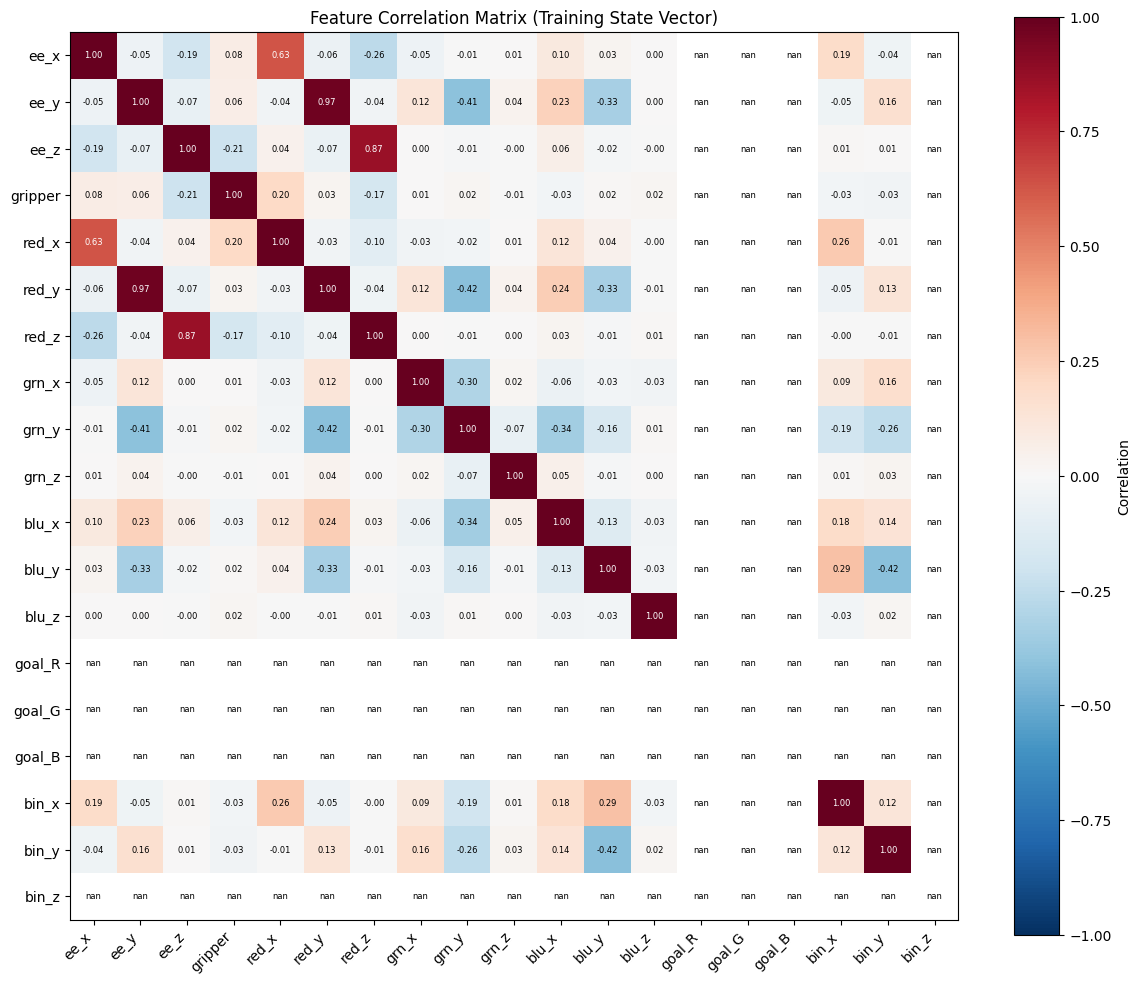

In [12]:
feature_names = [
    "ee_x", "ee_y", "ee_z",
    "gripper",
    "red_x", "red_y", "red_z",
    "grn_x", "grn_y", "grn_z",
    "blu_x", "blu_y", "blu_z",
    "goal_R", "goal_G", "goal_B",
    "bin_x", "bin_y", "bin_z",
]
features = np.column_stack([
    ee[:, :3],
    gripper_state,
    cube_red, cube_green, cube_blue,
    goal,
    goal_pos,
])

corr = np.corrcoef(features.T)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right")
ax.set_yticklabels(feature_names)
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(corr[i, j]) > 0.6 else "black")
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature Correlation Matrix (Training State Vector)")
plt.tight_layout()
plt.show()